# **Objective**
Telecom companies face major losses when customers discontinue their service (i.e., churn).

In this project, you will analyze customer data to predict whether a customer will churn and evaluate the performance of multiple classification models.

You will apply and compare three key supervised learning algorithms:

- Logistic Regression

- K-Nearest Neighbors (KNN)

- Decision Tree

- Random Forest Classifier

You will also explore evaluation metrics such as the confusion matrix, precision, recall, F1 score, and ROC-AUC to assess model performance.

#**Tasks and Deliverables**

In [173]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

## Part 1: Data Understanding and Preparation

Load the Telco Customer Churn dataset.

Explore the dataset:

- Check for missing values and data types.

- Summarize key statistics and visualize important relationships.

- Explore the churn distribution (target balance).

### Clean and preprocess the data:

- Handle missing or blank values (e.g., in TotalCharges).

- Encode categorical features appropriately.

- Scale numerical features if required (especially for KNN).

- Split the data into training and testing sets.



In [174]:

# Load Dataset from kaggle
url = "/content/drive/MyDrive/AI ML Engineering Bootcamp/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)
# initial 5 rows
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [175]:
# last 5 rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [176]:
# Shape
df.shape

(7043, 21)

In [177]:
# List of columns.
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [178]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [179]:
# TotalCharge cant be an object. we convert it into numeric value
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [180]:
# Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [181]:
# Fill Missing Values
median_charge = df["TotalCharges"].median()
df['TotalCharges']=df["TotalCharges"].fillna(median_charge)
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [182]:
# Summarize Key Statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [183]:
# Visualize Important Relationships
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


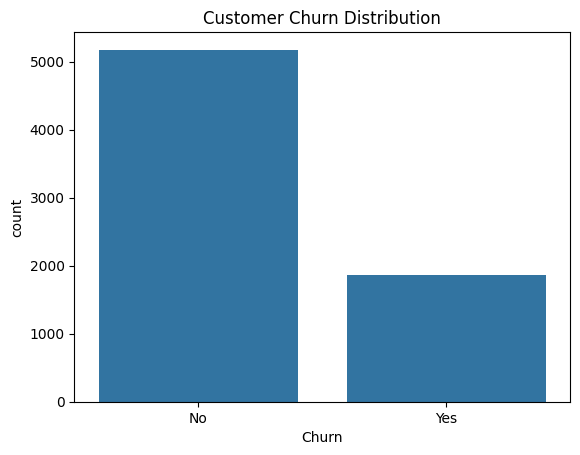

In [184]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

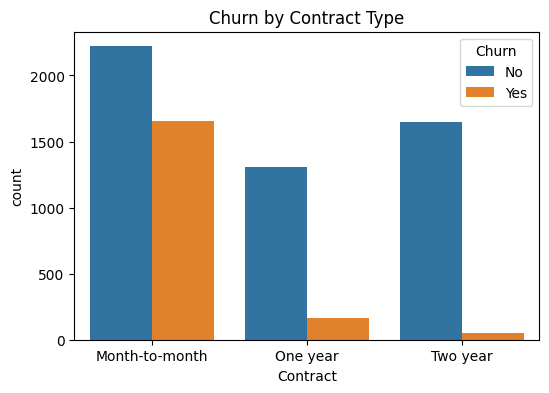

In [185]:
# Churn vs Contract Type
plt.figure(figsize=(6,4))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")

plt.show()

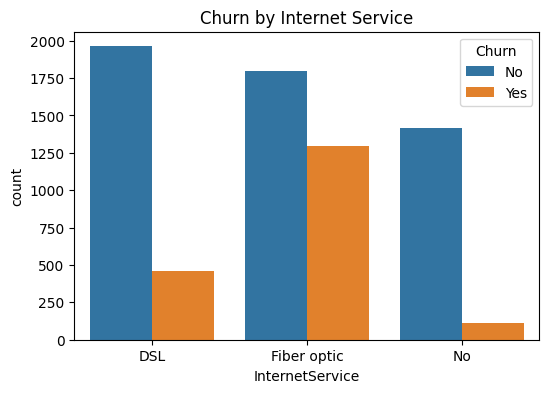

In [186]:
# Churn vs Internet Service
plt.figure(figsize=(6,4))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Churn by Internet Service")

plt.show()

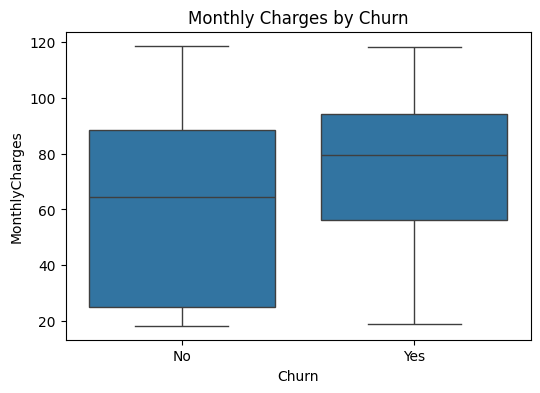

In [187]:
# Monthly Charges vs Churn
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges by Churn")

plt.show()

In [188]:
# Encode Categorical Features
# Binary Encoding
# these feature have only two categories
binary_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for col in binary_columns:

    df[col] = df[col].map({
        "Yes":1,
        "No":0,
        "Male":1,
        "Female":0
    })



In [189]:
df.select_dtypes(include="object").columns

Index(['customerID', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaymentMethod'],
      dtype='object')

In [190]:
# Separate Features and Target
X = df.drop(["customerID","Churn"], axis=1)

y = df["Churn"]

# One-Hot Encode all remaining categorical columns
X = pd.get_dummies(X, drop_first=True)

In [191]:
# Scale Numerical Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [192]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True))

Training Shape: (5634, 30)
Testing Shape: (1409, 30)

Training Target Distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Target Distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [193]:
# Scale the Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
# Part 2: Model Implementation

**A. Logistic Regression**

- Explain the concept of logistic regression and sigmoid function.

- Train a logistic regression model to predict customer churn.

- Evaluate its performance using classification metrics.

**B. K-Nearest Neighbors (KNN)**

- Explain how KNN predicts outcomes based on distance to neighboring points.

- Experiment with different values of K (e.g., 3, 5, 7, 9) and compare results.

- Discuss the impact of scaling and the choice of K on performance.

**C. Decision Tree**

- Explain how decision trees work.

- Train a decision tree classifier.

- Experiment with hyperparameters like max_depth or min_samples_leaf to avoid overfitting.

**D. Random Forest Classifier**

- Introduce Random Forest as an ensemble of decision trees.

- Train a Random Forest model and tune key hyperparameters such as:

    - n_estimators (number of trees)

    - max_depth

    - max_features

- Compare feature importances with the single decision tree model.
---

# A. Logistic Regression

# What is Logistic Regression?

Despite its name, Logistic Regression is a classification algorithm, not a regression algorithm.

Its job is to predict the probability that a customer will churn.

Instead of producing any number like Linear Regression, it produces values between 0 and 1.

**Example:**

Probability      ---------> Prediction

0.15          ---------------->    No Churn




0.82----------------->Churn

Usually,

Probability ≥ 0.5 → Churn (1)

Probability < 0.5 → No Churn (0)

# What is Sigmoid Function?
Logistic Regression uses the Sigmoid Function.
 P == 1 / (1 + e^-z)
where

z=w1x1 + w2x2 +⋯+b

**Why do we need Sigmoid?**

Without sigmoid:
-5,
3,
18,
100

These are not probabilities.

After sigmoid:

Input---------->Output




-5-------------->0.006




0--------------->0.50




5--------------->0.99


Now every output is between 0 and 1.

This makes it perfect for binary classification.

**Visualization**

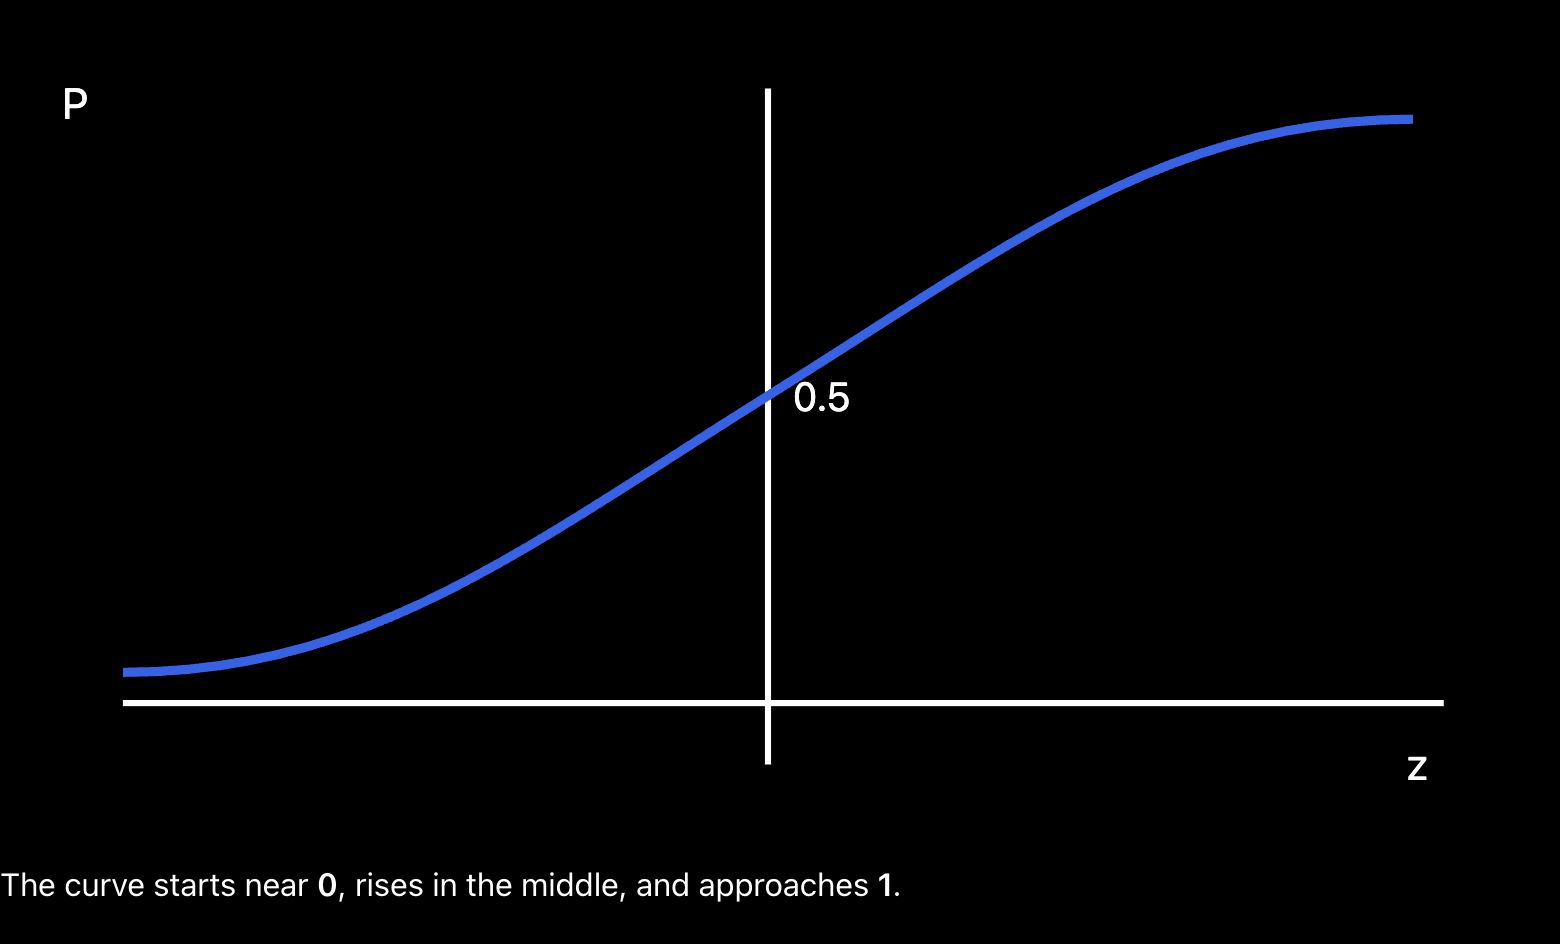

In [194]:
# Train Logistic Regression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [195]:
# Make Predictions
log_pred = log_model.predict(X_test_scaled)

log_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [196]:
# Evaluate Logistic Regression
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_prob))

Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1 Score: 0.6091954022988506
ROC-AUC: 0.8415846443979436


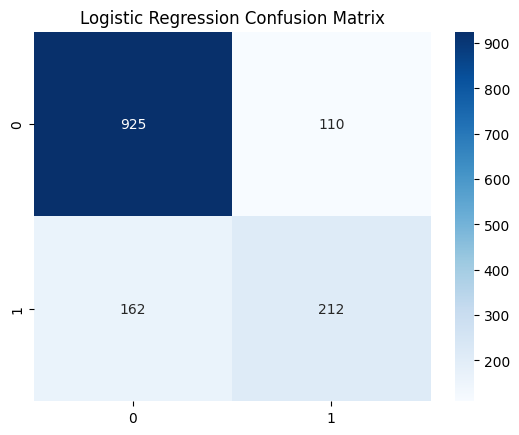

In [197]:
# Confusion matric
sns.heatmap(
    confusion_matrix(y_test, log_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

---
# B. K-Nearest Neighbors (KNN)
---

K-Nearest Neighbors (KNN) is a simple, supervised machine learning algorithm used for both classification and regression tasks.

KNN doesn't learn equations.

Instead,

it looks at nearby customers.

**Imagine:**

A new customer arrives.

Nearby customers:

Yes,
Yes,
No

If K=3

**Prediction:**

Yes

because 2 out of 3 neighbors churned.

---
Why Scaling Matters

Suppose two features:

Featur--------->Range




Tenure------------> 0–72




TotalCharges------>0–8000

Distance becomes dominated by TotalCharges.

Scaling fixes this.

This is why we use:

```
X_train_scaled
X_test_scaled
```



In [198]:
# Train Multiple K Values

k_values = [3,5,7,9]

knn_results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)

    knn_results.append((k, acc))

    print(f"K={k}, Accuracy={acc:.4f}")

K=3, Accuracy=0.7438
K=5, Accuracy=0.7473
K=7, Accuracy=0.7594
K=9, Accuracy=0.7700


In [199]:
# Compare K Values
knn_df = pd.DataFrame(
    knn_results,
    columns=["K","Accuracy"]
)

knn_df

,K,Accuracy
0,3,0.743790
1,5,0.747339
2,7,0.759404
3,9,0.770050


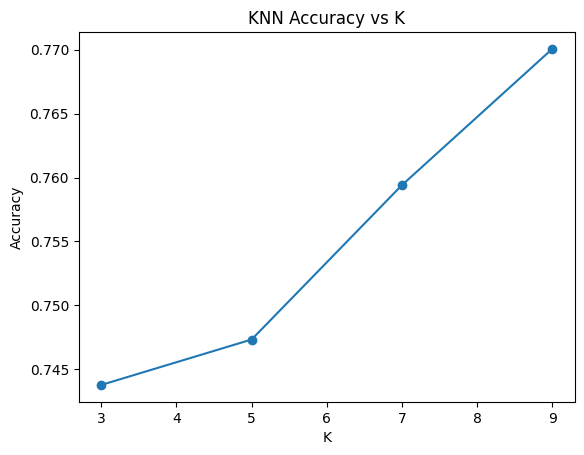

In [200]:
# Plot
plt.plot(
    knn_df["K"],
    knn_df["Accuracy"],
    marker="o"
)

plt.title("KNN Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

## Discussion
#### **Small K**

**Example:**

- K=1

    - very sensitive

    - noisy

    - High variance.

### **Large K**

**Example:**

- K=25

    - smoother

    - may underfit

    - High bias.

Usually,

moderate K works best.

---
## C. Decision Tree
---
**Explain how decision trees work?**


A decision tree works by repeatedly splitting a dataset into smaller, more specific groups based on simple "yes or no" questions about its features until it can make a reliable prediction

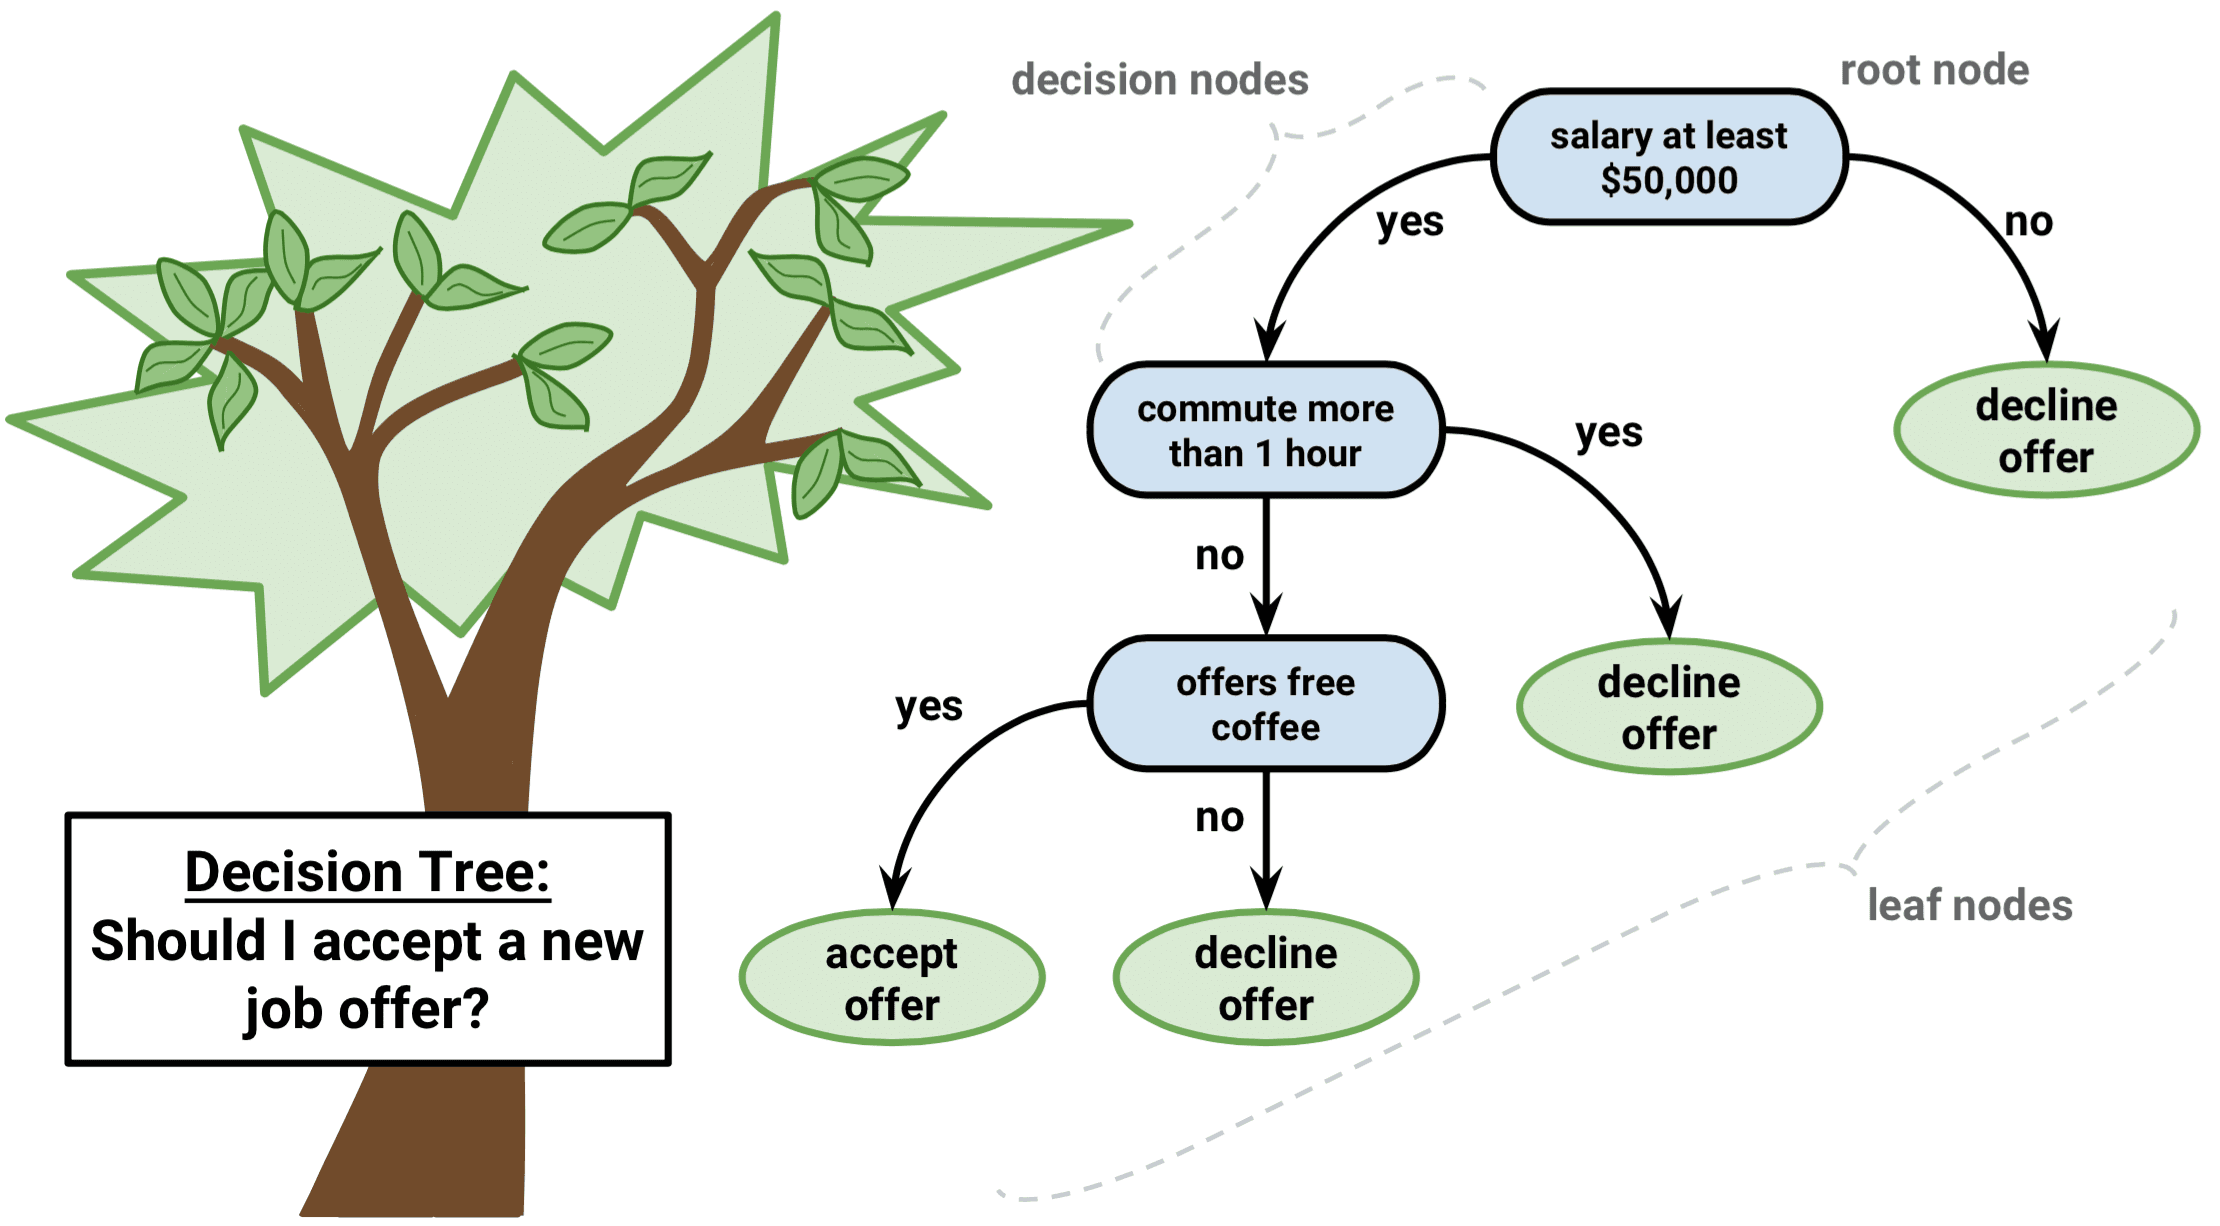


In [201]:
# Train Decision Tree


tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)

### Why these hyperparameters?

- max_depth

- Maximum tree depth.

Without it,

the tree can memorize training data.

**min_samples_leaf=5**

Every leaf must contain at least 5 samples.

This reduces overfitting.

In [202]:
# Experiment
depths = [3,5,7,10]
min_samples_leaf = [5,10,12,15]

"""
Loop through them and

Observe accuracy.

for which combination it provides the best prediction
"""


'\nLoop through them and\n\nObserve accuracy.\n\nfor which combination it provides the best prediction\n'

In [203]:
# Feature Importance
tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
)

tree_importance.sort_values(
    ascending=False
).head(10)

,0
tenure,0.422911
InternetService_Fiber optic,0.358794
TotalCharges,0.042836
PaymentMethod_Electronic check,0.036890
MultipleLines_Yes,0.023713
StreamingMovies_No internet service,0.020741
Contract_Two year,0.020623
StreamingTV_No internet service,0.017440
MonthlyCharges,0.016906
TechSupport_Yes,0.013034


---
# D. Random Forest
---
Random Forest is a powerful ensemble machine learning method that operates by constructing a large crowd of individual decision trees at training time. It is built on a simple yet highly effective principle: the collective wisdom of many weak learners outweighs the prediction of any single expert.

While a single decision tree is prone to high variance and overfitting, a Random Forest corrects this habit by forcing diversity among its trees and combining their final outputs.

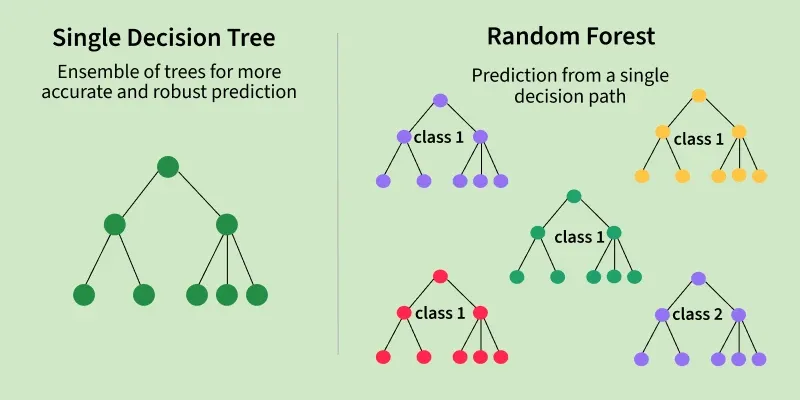



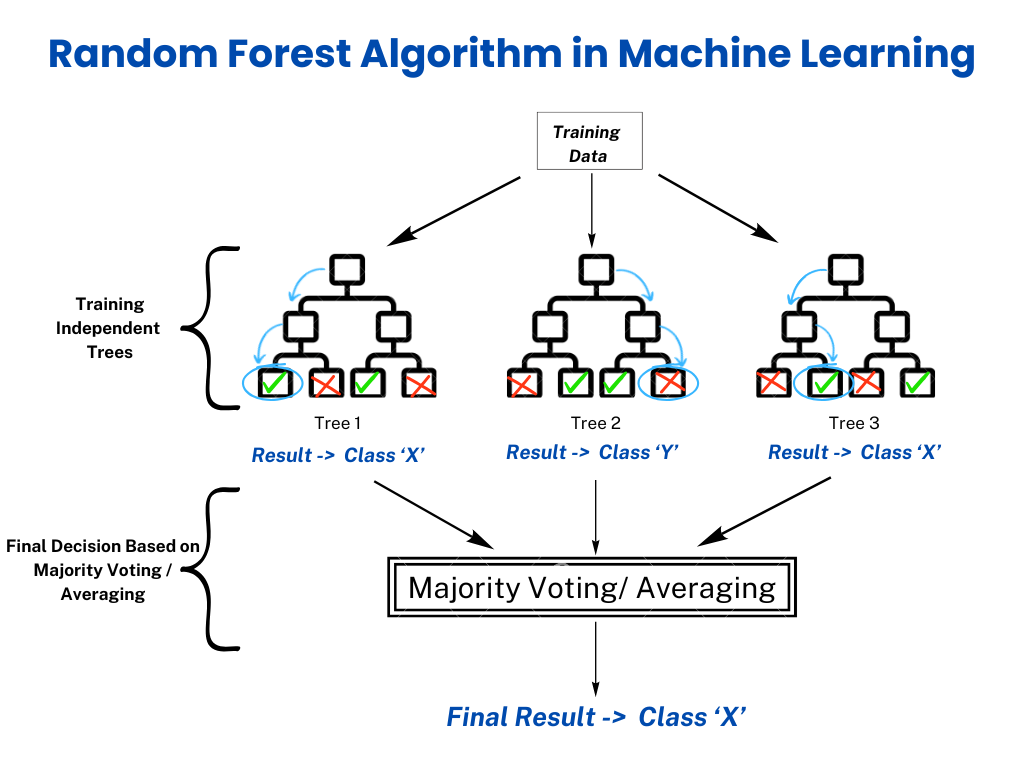

In [204]:
# Train Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    max_features="sqrt",
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

### Hyperparameters
- n_estimators

    - Number of trees.

**Example:**

10

100

200

More trees usually improve stability but increase training time.

- max_depth

    - Limits tree growth.

- max_features="sqrt"

    - Each split considers only a subset of features.

This increases diversity among trees.

In [205]:
# Feature Importance
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

rf_importance.sort_values(
    ascending=False
).head(10)

,0
tenure,0.195883
TotalCharges,0.154663
MonthlyCharges,0.100267
InternetService_Fiber optic,0.080663
Contract_Two year,0.072715
PaymentMethod_Electronic check,0.071824
Contract_One year,0.035787
OnlineSecurity_Yes,0.035012
TechSupport_Yes,0.027454
PaperlessBilling,0.021848


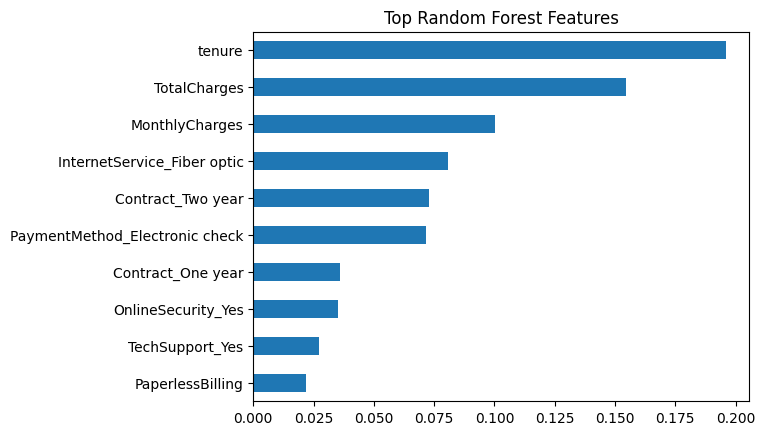

In [206]:
rf_importance.sort_values().tail(10).plot(kind="barh")

plt.title("Top Random Forest Features")

plt.show()

In [207]:
# Compare Decision Tree vs Random Forest
comparison = pd.DataFrame({
    "Decision Tree": tree_importance,
    "Random Forest": rf_importance
})

comparison.sort_values(
    "Random Forest",
    ascending=False
).head(10)

,Decision Tree,Random Forest
tenure,0.422911,0.195883
TotalCharges,0.042836,0.154663
MonthlyCharges,0.016906,0.100267
InternetService_Fiber optic,0.358794,0.080663
Contract_Two year,0.020623,0.072715
PaymentMethod_Electronic check,0.036890,0.071824
Contract_One year,0.008583,0.035787
OnlineSecurity_Yes,0.006651,0.035012
TechSupport_Yes,0.013034,0.027454
PaperlessBilling,0.000000,0.021848


In [208]:
# Evaluate Decision Tree & Random Forest
tree_pred = tree.predict(X_test)

print(classification_report(y_test, tree_pred))


              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [209]:
# Random Forest:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, rf_pred))

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8437973081195588


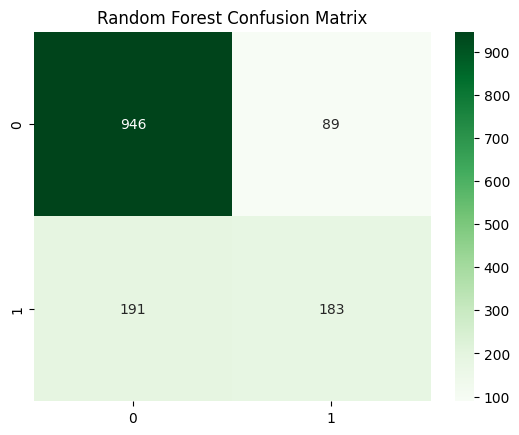

In [210]:
# Confusion Matrix:
sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

# **Part 3: Model Evaluation**

**For each model, compute and interpret:**

- Confusion Matrix

    - True Positives (TP), False Positives (FP), True Negatives (TN), False Negatives (FN)

- Precision, Recall, F1 Score, and Accuracy

- Plot and interpret the ROC curve and compute the ROC-AUC score for each model.

- Compare all models using a performance summary table.

**Discuss:**

- Which model performs best overall?

- Which metric (precision or recall) is more important for this business problem?

- Trade-offs between model interpretability and performance.

In [211]:
# A Reusable Evaluation Function

def evaluate_model(model, X_test, y_test, model_name, scaled=False):

    # Make predictions
    y_pred = model.predict(X_test)

    # Get probability scores (needed for ROC)
    y_prob = model.predict_proba(X_test)[:,1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    # Print results
    print("="*50)
    print(model_name)
    print("="*50)

    print("Confusion Matrix:")
    print(cm)

    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Draw confusion matrix
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues")

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    print("="*50)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(5,4))

    plt.plot(fpr, tpr,
             label=f"AUC={roc_auc_score(y_test,y_prob):.3f}")

    plt.plot([0,1],[0,1],"--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"{model_name} ROC Curve")

    plt.legend()

    plt.show()

    # Return metrics
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test,y_pred),
        "Precision": precision_score(y_test,y_pred),
        "Recall": recall_score(y_test,y_pred),
        "F1": f1_score(y_test,y_pred),
        "ROC-AUC": roc_auc_score(y_test,y_prob)
    }

Logistic Regression
Confusion Matrix:
[[925 110]
 [162 212]]
TN=925, FP=110, FN=162, TP=212

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



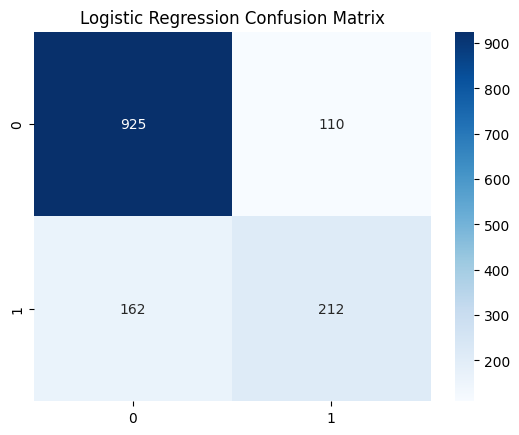

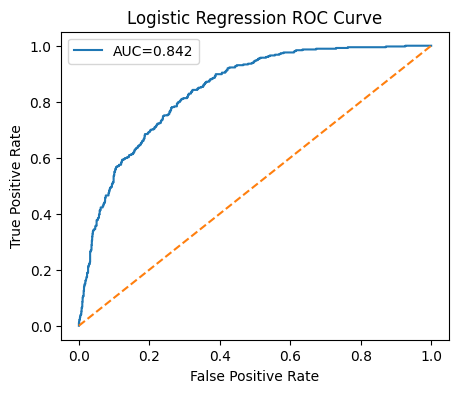

In [212]:
# Evaluate Logistic Regression
log_results = evaluate_model(
    log_model,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)

KNN
Confusion Matrix:
[[866 169]
 [187 187]]
TN=866, FP=169, FN=187, TP=187

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1035
           1       0.53      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.75      1409



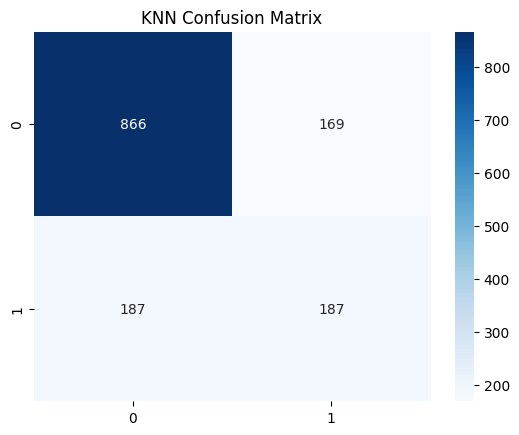

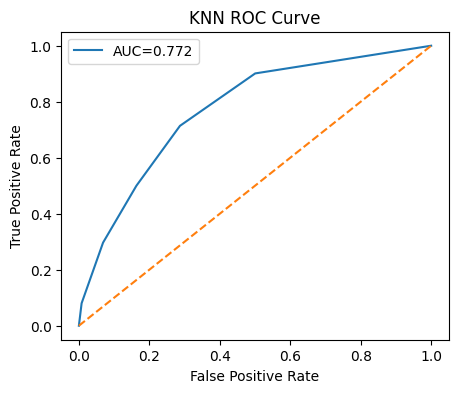

In [213]:
# Evaluate KNN
best_knn = KNeighborsClassifier(n_neighbors=5)

best_knn.fit(X_train_scaled,y_train)

knn_results = evaluate_model(
    best_knn,
    X_test_scaled,
    y_test,
    "KNN"
)

Decision Tree
Confusion Matrix:
[[915 120]
 [170 204]]
TN=915, FP=120, FN=170, TP=204

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



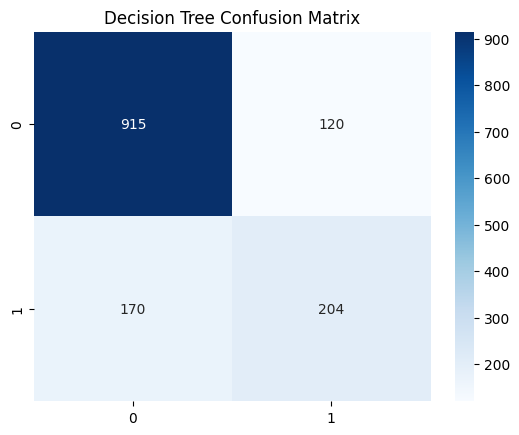

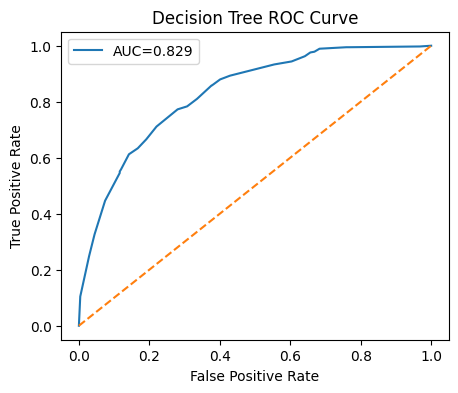

In [214]:
# Evaluate Decision Tree
tree_results = evaluate_model(
    tree,
    X_test,
    y_test,
    "Decision Tree"
)

Random Forest
Confusion Matrix:
[[946  89]
 [191 183]]
TN=946, FP=89, FN=191, TP=183

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



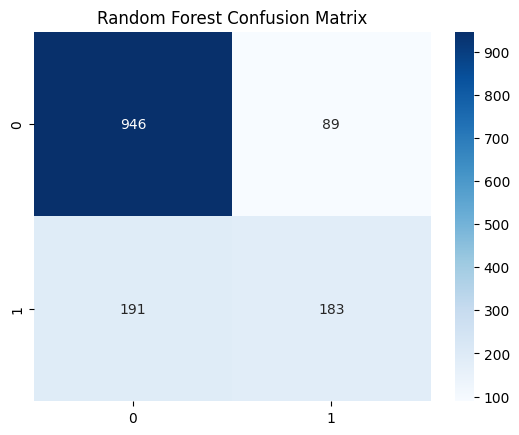

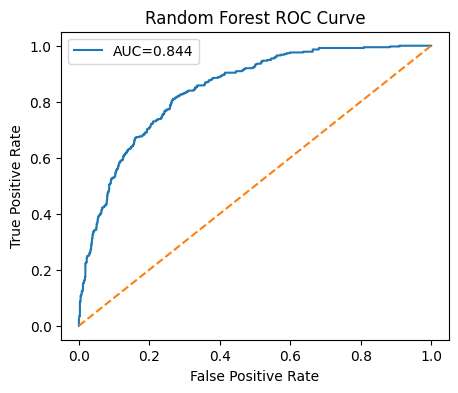

In [215]:
# Evaluate Random Forest

rf_results = evaluate_model(
    rf,
    X_test,
    y_test,
    "Random Forest"
)

In [216]:
# Compare All Models
summary = pd.DataFrame([
    log_results,
    knn_results,
    tree_results,
    rf_results
])

summary = summary.round(3)

summary

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.807,0.658,0.567,0.609,0.842
1,KNN,0.747,0.525,0.500,0.512,0.772
2,Decision Tree,0.794,0.630,0.545,0.585,0.829
3,Random Forest,0.801,0.673,0.489,0.567,0.844


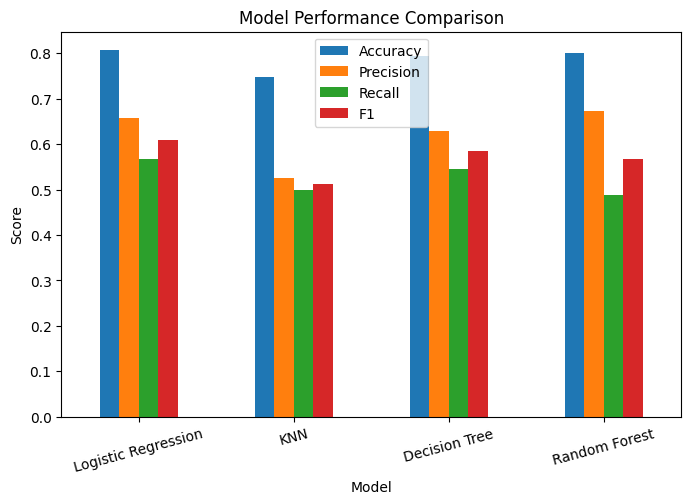

In [217]:
# Visualize
summary.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.show()

---
### 1. Which model performs best overall?

Based on the evaluation metrics, Logistic Regression performs best overall for this customer churn prediction task.

* Highest Accuracy: 80.7%

* Highest Recall: 56.7%

* Highest F1 Score: 60.9%

* Strong ROC-AUC: 84.2%

Although Random Forest achieves the highest Precision (67.3%) and the highest ROC-AUC (84.4%), its Recall is the lowest (48.9%), meaning it misses more actual churning customers. Since identifying customers who are likely to leave is important in churn prediction, Logistic Regression provides the best overall balance.

### 2. Which metric (Precision or Recall) is more important for this business problem?

For a telecom customer churn prediction system, Recall is more important than Precision.

Recall measures how many actual churning customers are correctly identified.

Recall= TP / (TP + FN)

### Why Recall matters more

* False Negative (FN): A customer who is actually going to churn is predicted as "No Churn." The company loses that customer and future revenue.

* False Positive (FP): A loyal customer is predicted to churn. The company may send an unnecessary discount or retention offer, which usually costs less than losing a customer.

Therefore, businesses typically prioritize Recall to identify as many at-risk customers as possible.

### 3. Trade-offs Between Model Interpretability and Performance

Different models offer different balances between explainability and predictive performance.

### Interpretation

* Logistic Regression is easy to explain because each feature has a clear influence on the prediction while still providing the best overall performance.

* Decision Tree is highly interpretable since its decision rules can be visualized, but it performs slightly worse.

* Random Forest generally provides excellent predictive performance and the highest ROC-AUC, but its ensemble of many trees makes it much harder to interpret.

* KNN is simple conceptually but performed the weakest on this dataset.

### Final Recommendation

For this assignment, Logistic Regression is the recommended model because it achieves the best balance of Accuracy, Recall, and F1 Score while remaining easy to interpret. In a real-world telecom setting, a tuned Random Forest could also be considered if maximizing predictive performance is the primary objective.


---
# **Part 4: Insights and Conclusion**

**Write a brief report summarizing:**

- Key factors that influence customer churn.

- Which model you recommend for deployment and why.

- Business implications of false positives and false negatives.

- Limitations of your approach and potential improvements.

---
### 4.1 Key Factors That Influence Customer Churn

The exploratory data analysis and model training indicate that several customer attributes have a strong influence on churn behavior. Customers with month-to-month contracts were more likely to leave compared to those with one-year or two-year contracts. Customers with higher monthly charges and shorter tenure also showed a greater tendency to churn. Features such as Internet Service, Payment Method, and Paperless Billing also contributed to predicting whether a customer would discontinue the service.

### 4.2 Recommended Model for Deployment

Based on the experimental results, Logistic Regression is the recommended model for deployment.

### Model Performance Summary

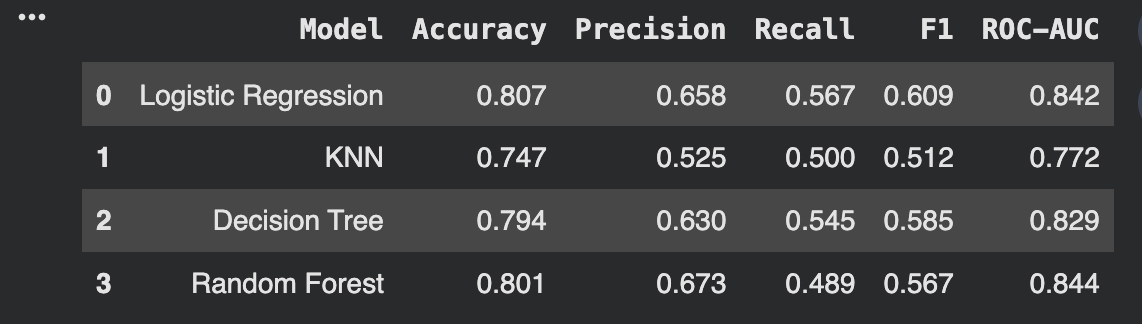

### Why Logistic Regression?

Logistic Regression provides the best overall balance of performance for this dataset because it achieves:

* Highest Accuracy (80.7%)

* Highest Recall (56.7%)

* Highest F1 Score (60.9%)

* Strong ROC-AUC (84.2%)

Although Random Forest achieved the highest Precision and ROC-AUC, its lower Recall means it misses more customers who are actually going to churn. Since identifying potential churners is critical for a telecom company, Logistic Regression is the most suitable choice for this assignment.

### 4.3 Business Implications of False Positives and False Negatives

Understanding prediction errors is important because each mistake has a different business cost.

### False Positive (FP)

A loyal customer is predicted to churn.

* The company may send an unnecessary discount or promotional offer.

* This creates additional marketing costs.

* However, the customer remains with the company.

### False Negative (FN)

A customer who is actually going to churn is predicted as "No Churn."

* The company misses the opportunity to retain that customer.

* Future subscription revenue is lost.

* Acquiring a new customer usually costs significantly more than retaining an existing one.

Therefore, False Negatives are generally more expensive than False Positives, which is why Recall is an important evaluation metric for churn prediction.

### 4.4 Limitations and Potential Improvements

### Limitations

* The dataset is imbalanced, with significantly more non-churn customers than churn customers.

* Default model parameters were used for most algorithms, which may not provide optimal performance.

* Only basic preprocessing techniques were applied without advanced feature engineering.

* The evaluation was based on a single train-test split rather than multiple validation folds.

### Potential Improvements

* Use GridSearchCV or RandomizedSearchCV to optimize hyperparameters.

* Apply Cross-Validation for more reliable performance estimation.

* Handle class imbalance using techniques such as SMOTE or class weighting.

* Perform additional feature engineering by creating new variables from tenure, charges, and customer behavior.

* Explore advanced boosting algorithms such as XGBoost, LightGBM, or CatBoost for potentially higher predictive performance.

### Final Conclusion

This project successfully developed a customer churn prediction system using four supervised learning algorithms: Logistic Regression, KNN, Decision Tree, and Random Forest. Among these models, Logistic Regression demonstrated the best overall balance of Accuracy, Recall, and F1 Score, making it the recommended model for deployment in this assignment. The analysis highlights that contract type, tenure, monthly charges, and internet-related services are key factors influencing customer churn. With further hyperparameter tuning, class imbalance handling, and advanced ensemble methods, the predictive performance of the churn prediction system could be improved even further.
